# Relatórios Visuais sobre o Desempenho de Vendas de uma Rede Varejista

**Configuração do Ambiente e Dados Iniciais**

Executando o bloco abaixo para carregar as bibliotecas e gerar a base de dados simulada para a atividade.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Gerando dados sintéticos estruturados
np.random.seed(42)
n_registros = 120

datas = pd.date_range(start='2024-01-01', periods=n_registros, freq='D')
categorias = ['Eletronicos', 'Livros', 'Roupas', 'Automotivo']
estados = ['SP', 'RJ', 'MG', 'RS', 'BA']

dados = {
    'data': datas,
    'categoria': np.random.choice(categorias, size=n_registros),
    'estado': np.random.choice(estados, size=n_registros),
    'valor': np.random.uniform(50, 4500, size=n_registros).round(2),
    'quantidade': np.random.randint(1, 15, size=n_registros),
}

df = pd.DataFrame(dados)
df['valor_venda'] = (df['valor'] * np.random.uniform(0.9, 1.1, size=n_registros)).round(2)

**Parte 1: Gráficos Essenciais e Personalização (Básico)**

1 - Faturamento mensal total

In [ ]:
df['data'] = pd.to_datetime(df['data'])

faturamento_mensal = (
    df.set_index('data')['valor_venda']
      .resample('ME')
      .sum()
)

plt.figure(figsize=(10, 5))

plt.plot(
    faturamento_mensal.index,
    faturamento_mensal.values,
    marker='o',
    linestyle='--',
    color='royalblue'
)

plt.title('Faturamento mensal total')
plt.xlabel('Mês')
plt.ylabel('Faturamento (R$)')
plt.grid(True)

plt.show()


2 - Total de vendas por categoria

In [ ]:
vendas_categoria = (
    df.groupby('categoria')['valor_venda']
      .sum()
      .sort_values()
)

plt.figure(figsize=(9, 5))

plt.bar(
    vendas_categoria.index,
    vendas_categoria.values,
    color='seagreen'
)

plt.title('Total de vendas por categoria')
plt.xlabel('Categoria')
plt.ylabel('Total de vendas (R$)')

plt.xticks(rotation=45)

plt.show()

3 - Histograma dos valores

In [ ]:
plt.figure(figsize=(9, 5))

plt.hist(
    df['valor'],
    bins=10,
    edgecolor='black',
    color='skyblue'
)

plt.title('Distribuição dos valores das vendas')
plt.xlabel('Valor')
plt.ylabel('Frequência')

plt.show()


**Parte 2: API Orientada a Objetos e Eixos Múltiplos (Intermediário)**

1 - Subplots 2 × 1 com eixo X compartilhado

In [ ]:
df['data'] = pd.to_datetime(df['data'])

df_mensal = (
    df.set_index('data')
      .resample('ME')
      .agg(
          faturamento=('valor_venda', 'sum'),
          quantidade_itens=('quantidade', 'sum')
      )
)

fig, (ax1, ax2) = plt.subplots(
    2, 1,
    figsize=(12, 8),
    sharex=True
)

# Faturamento mensal

ax1.plot(
    df_mensal.index,
    df_mensal['faturamento'],
    marker='o',
    linestyle='--',
    color='royalblue'
)

ax1.set_title('Faturamento mensal')
ax1.set_ylabel('Faturamento (R$)')
ax1.grid(True, alpha=0.3)

mes_maior = df_mensal['faturamento'].idxmax()
valor_maior = df_mensal['faturamento'].max()

ax1.annotate(
    f'Maior faturamento\nR$ {valor_maior:,.2f}',
    xy=(mes_maior, valor_maior),
    xytext=(20, 30),
    textcoords='offset points',
    arrowprops=dict(
        arrowstyle='->',
        color='red'
    ),
    color='red'
)

# Quantidade de itens vendidos

ax2.bar(
    df_mensal.index,
    df_mensal['quantidade_itens'],
    color='seagreen'
)

ax2.set_title('Quantidade total de itens vendidos por mês')
ax2.set_xlabel('Mês')
ax2.set_ylabel('Quantidade de itens')
ax2.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


2 - Gráfico com dois eixos Y

In [ ]:
df_mensal_2 = (
    df.set_index('data')
      .resample('ME')
      .agg(
          valor_total=('valor_venda', 'sum'),
          quantidade_media=('quantidade', 'mean')
      )
)

fig, ax = plt.subplots(figsize=(12, 6))

ax.bar(
    df_mensal_2.index,
    df_mensal_2['valor_total'],
    color='steelblue',
    alpha=0.7,
    label='Valor total vendido'
)

ax.set_xlabel('Mês')
ax.set_ylabel('Valor total vendido (R$)', color='steelblue')
ax.tick_params(axis='y', labelcolor='steelblue')
ax.grid(True, axis='y', alpha=0.3)

ax2 = ax.twinx()

ax2.plot(
    df_mensal_2.index,
    df_mensal_2['quantidade_media'],
    color='darkorange',
    marker='o',
    linewidth=2,
    label='Quantidade média por venda'
)

ax2.set_ylabel(
    'Quantidade média de itens por venda',
    color='darkorange'
)
ax2.tick_params(axis='y', labelcolor='darkorange')

plt.title('Valor total vendido e quantidade média de itens por venda')
fig.tight_layout()

plt.show()

**Parte 3: Matriz de Intensidade / Heatmap (Intermediário / Avançado)**

1 - Tabela dinâmica

In [6]:
tabela_vendas = pd.pivot_table(
    df,
    values='valor_venda',
    index='categoria',
    columns='estado',
    aggfunc='sum'
)

print(tabela_vendas)

estado             BA        MG        RJ        RS        SP
categoria                                                    
Automotivo    6992.96  16333.39  26783.38  10122.88  26727.57
Eletronicos  14211.94  13453.06   1154.47  13966.62   9372.80
Livros        4318.03  25667.11   9659.57  19302.59  23104.72
Roupas       26968.88   9876.74  11120.83   4809.04  14856.77


2 - Heatmap com 'plt.imshow()'

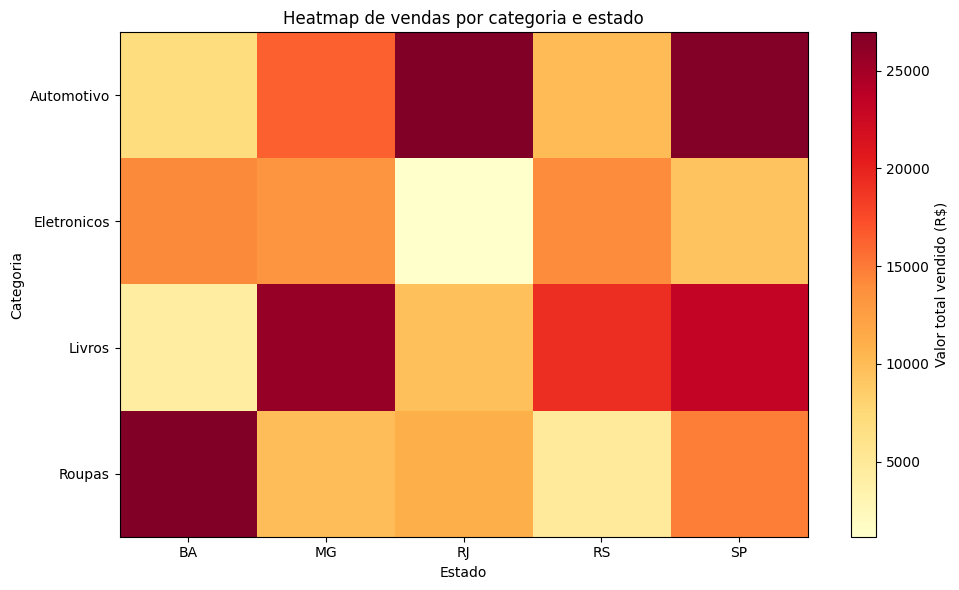

In [7]:
plt.figure(figsize=(10, 6))

imagem = plt.imshow(
    tabela_vendas.values,
    cmap='YlOrRd',
    aspect='auto'
)

plt.colorbar(imagem, label='Valor total vendido (R$)')

plt.xticks(
    ticks=np.arange(len(tabela_vendas.columns)),
    labels=tabela_vendas.columns
)

plt.yticks(
    ticks=np.arange(len(tabela_vendas.index)),
    labels=tabela_vendas.index
)

plt.xlabel('Estado')
plt.ylabel('Categoria')
plt.title('Heatmap de vendas por categoria e estado')

plt.tight_layout()

plt.show()


3 - Salvando a figura em PNG

In [8]:
plt.savefig(
    'heatmap_vendas.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

<Figure size 640x480 with 0 Axes>